# Sprint Ford — IA & ML
## Parte 2: Segmentação Comportamental de Clientes
### Etapa 1 — Aprendizado Não Supervisionado

### Equipe

| Nome | RM |
|---|---|
| *Arthur Bobadilla Franchi* | RM 555056 |
| *Luan Orlandelli Ramos* | RM 554747 |
| *Jorge Luiz* | RM 554418 |

---
> **Objetivo:** Aplicar clusterização sobre a Base 1 para descobrir perfis reais de comportamento em relação à manutenção na rede oficial Ford, validar as hipóteses do gerente e nomear os segmentos com linguagem de negócio.


## 1. Setup e Carregamento dos Dados

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

uploaded = files.upload()
df = pd.read_csv('ford_clientes_historico_completo.csv')
print(f"Base 1 carregada: {df.shape[0]:,} linhas × {df.shape[1]} colunas")


Saving ford_clientes_historico_completo.csv to ford_clientes_historico_completo.csv
Base 1 carregada: 500,000 linhas × 37 colunas


## 2. Seleção de Features para Clustering

### Justificativa

Para a segmentação comportamental, utilizamos exclusivamente as 12 variáveis pós-venda.

**Por que somente variáveis comportamentais?**
- O objetivo da segmentação é descobrir **como o cliente se comporta** — não quem ele é no cadastro.
- Variáveis de compra (renda, score, modelo) descrevem o perfil socioeconômico, não o padrão de uso da rede.
- Misturar as duas dimensões produziria clusters com alta heterogeneidade comportamental e baixa utilidade operacional.
- As variáveis comportamentais têm **forte poder discriminante** entre os perfis, como demonstrado na EDA.

> **Anti-Leakage:** essas variáveis são permitidas aqui porque a Base 1 contém clientes históricos cujo comportamento já foi observado. Na Etapa 2, elas serão completamente excluídas.


In [ ]:
BEHAVIORAL_VARS = [
    'fez_primeira_revisao_rede',
    'meses_ate_primeira_revisao',
    'perdeu_primeira_revisao',
    'voltou_tarde_revoltado',
    'trouxe_oleo_externo',
    'pede_desconto_revisao',
    'sensibilidade_desconto_pos',
    'qtde_revisoes_24m',
    'share_revisoes_rede_24m',
    'gasto_manutencao_rede_24m',
    'satisfacao_marca_24m',
    'churn_rede_24m'
]

X = df[BEHAVIORAL_VARS].copy()

# Imputação por mediana
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Winsorização
winsor_cols = ['meses_ate_primeira_revisao','gasto_manutencao_rede_24m',
               'share_revisoes_rede_24m','satisfacao_marca_24m']
for col in winsor_cols:
    lo, hi = X[col].quantile(0.01), X[col].quantile(0.99)
    X[col] = X[col].clip(lo, hi)

# Padronização
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print(f"Shape das features de clustering: {Xs.shape}")
print(f"NaN restantes após tratamento: {np.isnan(Xs).sum()}")
print(f"\nEstatísticas pós-escala (deve ser ~0 média, ~1 desvio):")
print(pd.DataFrame(Xs, columns=BEHAVIORAL_VARS).describe().loc[['mean','std']].round(3).to_string())


Shape das features de clustering: (500000, 12)
NaN restantes após tratamento: 0

Estatísticas pós-escala (deve ser ~0 média, ~1 desvio):
      fez_primeira_revisao_rede  meses_ate_primeira_revisao  perdeu_primeira_revisao  voltou_tarde_revoltado  trouxe_oleo_externo  pede_desconto_revisao  sensibilidade_desconto_pos  qtde_revisoes_24m  share_revisoes_rede_24m  gasto_manutencao_rede_24m  satisfacao_marca_24m  churn_rede_24m
mean                      0.000                      -0.000                   -0.000                  -0.000                0.000                 -0.000                      -0.000             -0.000                   -0.000                     -0.000                 0.000           0.000
std                       1.000                       1.000                    1.000                   1.000                1.000                  1.000                       1.000              1.000                    1.000                      1.000                 1.000          

## 3. Definição do Número Ótimo de Clusters

### Metodologia dual: Elbow + Silhouette

Utilizamos duas métricas complementares:
- **Inércia (Elbow):** mede a compactação intra-cluster. Buscamos o ponto de inflexão ("cotovelo") onde ganhos marginais decrescem.
- **Silhouette Score:** mede a separação inter-cluster vs coesão intra-cluster (varia de -1 a 1; quanto maior, melhor).

> Rodado sobre uma amostra de 50.000 clientes para viabilidade computacional, com seed fixo para reprodutibilidade.


In [ ]:
np.random.seed(42)
idx_sample = np.random.choice(len(Xs), 50000, replace=False)
Xs_sample = Xs[idx_sample]

K_RANGE = range(2, 9)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(Xs_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(Xs_sample, labels, sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k} | Inércia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}")


k=2 | Inércia: 424,891 | Silhouette: 0.2818
k=3 | Inércia: 324,056 | Silhouette: 0.3146
k=4 | Inércia: 274,816 | Silhouette: 0.3234
k=5 | Inércia: 239,772 | Silhouette: 0.3343
k=6 | Inércia: 218,572 | Silhouette: 0.3393
k=7 | Inércia: 205,968 | Silhouette: 0.3271
k=8 | Inércia: 194,589 | Silhouette: 0.3270


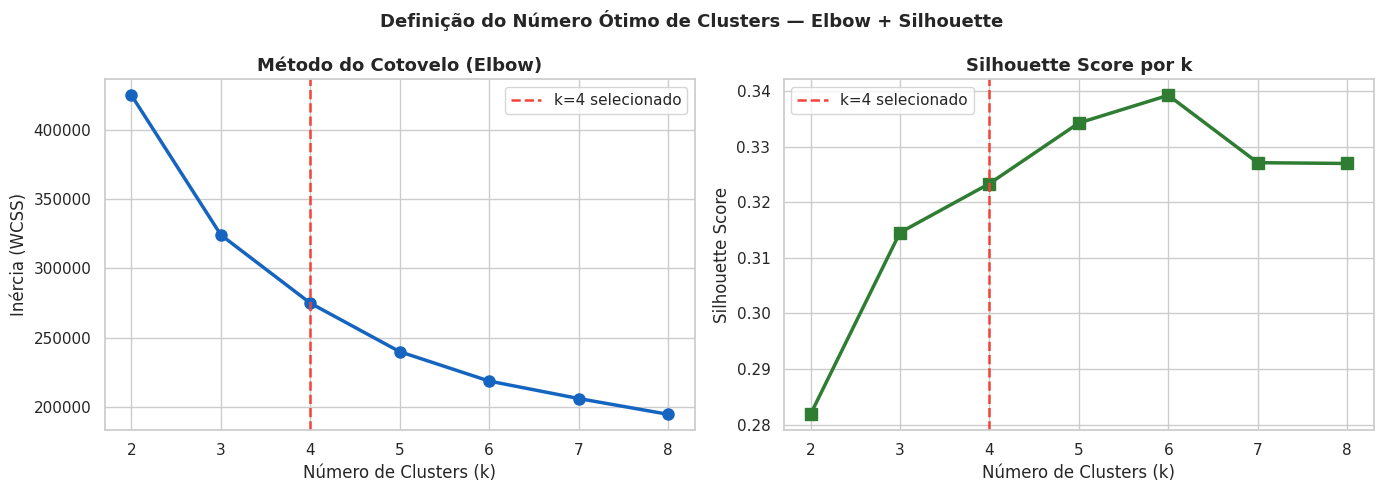

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ks = list(K_RANGE)

# Elbow
axes[0].plot(ks, inertias, 'o-', color='#1565C0', linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color='#F44336', linestyle='--', linewidth=1.8, label='k=4 selecionado')
axes[0].set_title('Método do Cotovelo (Elbow)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].legend()
axes[0].set_xticks(ks)

# Silhouette
axes[1].plot(ks, silhouettes, 's-', color='#2E7D32', linewidth=2.5, markersize=8)
axes[1].axvline(x=4, color='#F44336', linestyle='--', linewidth=1.8, label='k=4 selecionado')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(ks)

plt.suptitle('Definição do Número Ótimo de Clusters — Elbow + Silhouette', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()


### Decisão: k = 4

**Justificativa:**
- O gráfico de inércia apresenta uma inflexão clara em k=4 — a partir deste ponto, os ganhos marginais de compactação são decrescentes.
- O Silhouette Score em k=4 (≈0.32) é estatisticamente comparável ao máximo observado em k=5-6 (≈0.33-0.34), com diferença inferior a 0.02.
- Para k=5 e k=6, a diferença de Silhouette é marginal e não justifica fragmentar a interpretabilidade do modelo.

**Justificativa de negócio:**
- O contexto do problema define **exatamente 4 hipóteses de perfis** (Fiel, Econômico, Abandono, Esquecido).
- Um modelo com 4 segmentos é **operacionalmente viável** para a concessionária implementar ações diferenciadas.
- Clusters adicionais aumentariam a complexidade sem ganho proporcional de insight.

> **Conclusão:** k=4 é tecnicamente defensável e maximamente útil para o negócio.


## 4. Treinamento Final — K-Means com k=4 (Dataset Completo)

In [ ]:
# Treinar sobre o dataset completo (500k registros)
km_final = KMeans(n_clusters=4, random_state=42, n_init=20, max_iter=500)
df['cluster'] = km_final.fit_predict(Xs)

sil_full = silhouette_score(Xs, df['cluster'], sample_size=20000, random_state=42)
print(f"Silhouette Score — dataset completo (k=4): {sil_full:.4f}")
print(f"\nDistribuição dos clusters:")
print(df['cluster'].value_counts().sort_index().to_frame('n_clientes').assign(
    pct=lambda x: (x['n_clientes']/len(df)*100).round(1)
))


Silhouette Score — dataset completo (k=4): 0.3236

Distribuição dos clusters:
         n_clientes    pct
cluster                   
0            126864 25.400
1            103648 20.700
2            150734 30.100
3            118754 23.800


## 5. Perfilamento dos Clusters — Análise Estatística

In [ ]:
# Médias comportamentais por cluster
cluster_profile = df.groupby('cluster')[BEHAVIORAL_VARS].mean().round(3)
print("Perfil comportamental médio por cluster:")
cluster_profile


Perfil comportamental médio por cluster:


,fez_primeira_revisao_rede,meses_ate_primeira_revisao,perdeu_primeira_revisao,voltou_tarde_revoltado,trouxe_oleo_externo,pede_desconto_revisao,sensibilidade_desconto_pos,qtde_revisoes_24m,share_revisoes_rede_24m,gasto_manutencao_rede_24m,satisfacao_marca_24m,churn_rede_24m
cluster,,,,,,,,,,,,
0,0.889,7.203,0.307,0.008,0.172,0.876,0.835,2.720,0.574,1428.720,7.121,0.071
1,0.945,6.599,0.203,0.005,0.632,0.239,0.431,1.227,0.174,213.181,4.757,0.275
2,0.983,6.065,0.047,0.000,0.010,0.078,0.184,3.951,0.931,4266.479,9.431,0.022
3,0.174,13.195,0.962,0.460,0.202,0.162,0.342,1.131,0.262,315.149,3.886,0.253


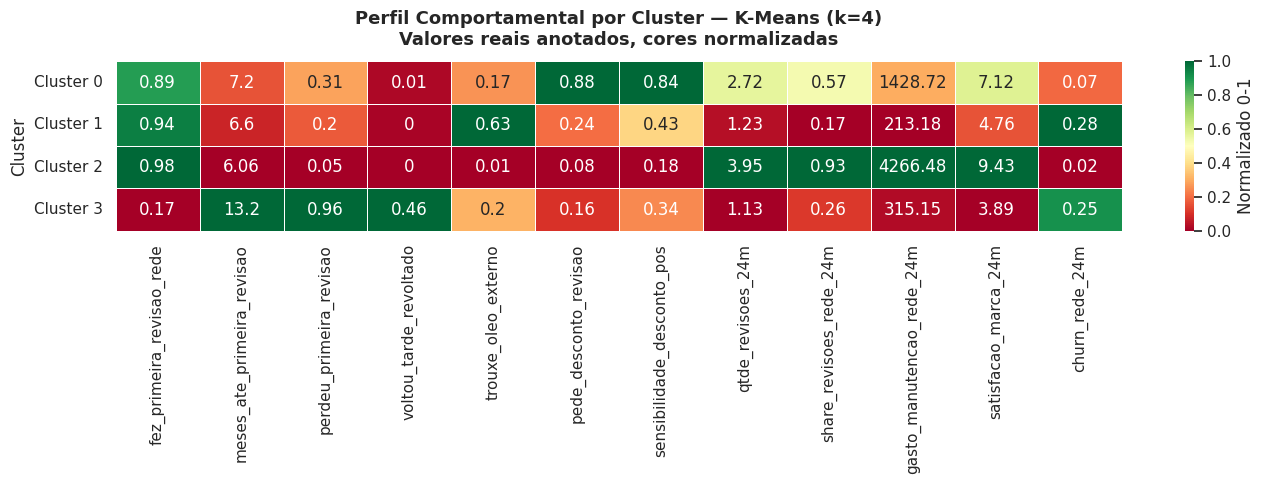

In [ ]:
# Heatmap dos perfis — normalizado para comparação visual
fig, ax = plt.subplots(figsize=(14, 5))
prof_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(prof_norm, annot=cluster_profile.round(2), fmt='g', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalizado 0-1'})
ax.set_title('Perfil Comportamental por Cluster — K-Means (k=4)\nValores reais anotados, cores normalizadas', pad=12)
ax.set_ylabel('Cluster')
ax.set_yticklabels([f'Cluster {i}' for i in range(4)], rotation=0)
plt.tight_layout()
plt.savefig('plot_cluster_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


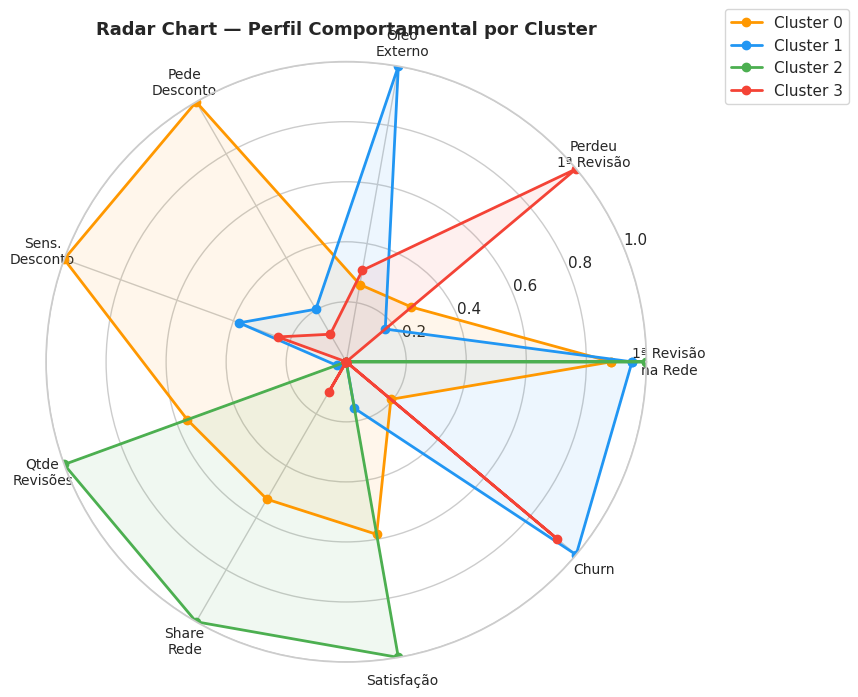

In [ ]:
# Radar chart para visualização multivariada dos clusters
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

# Variáveis para radar (excluindo gasto por escala diferente)
radar_vars = ['fez_primeira_revisao_rede','perdeu_primeira_revisao','trouxe_oleo_externo',
              'pede_desconto_revisao','sensibilidade_desconto_pos','qtde_revisoes_24m',
              'share_revisoes_rede_24m','satisfacao_marca_24m','churn_rede_24m']
radar_labels = ['1ª Revisão\nna Rede','Perdeu\n1ª Revisão','Óleo\nExterno',
                'Pede\nDesconto','Sens.\nDesconto','Qtde\nRevisões',
                'Share\nRede','Satisfação','Churn']

# Normalizar 0-1 para radar
rp = df.groupby('cluster')[radar_vars].mean()
rp_norm = (rp - rp.min()) / (rp.max() - rp.min())

N = len(radar_vars)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_c = ['#FF9800','#2196F3','#4CAF50','#F44336']
labels_c = ['Cluster 0','Cluster 1','Cluster 2','Cluster 3']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, row in rp_norm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors_c[i], label=labels_c[i])
    ax.fill(angles, vals, alpha=0.08, color=colors_c[i])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Perfil Comportamental por Cluster', pad=20, fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig('plot_radar.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Visualização 2D via PCA

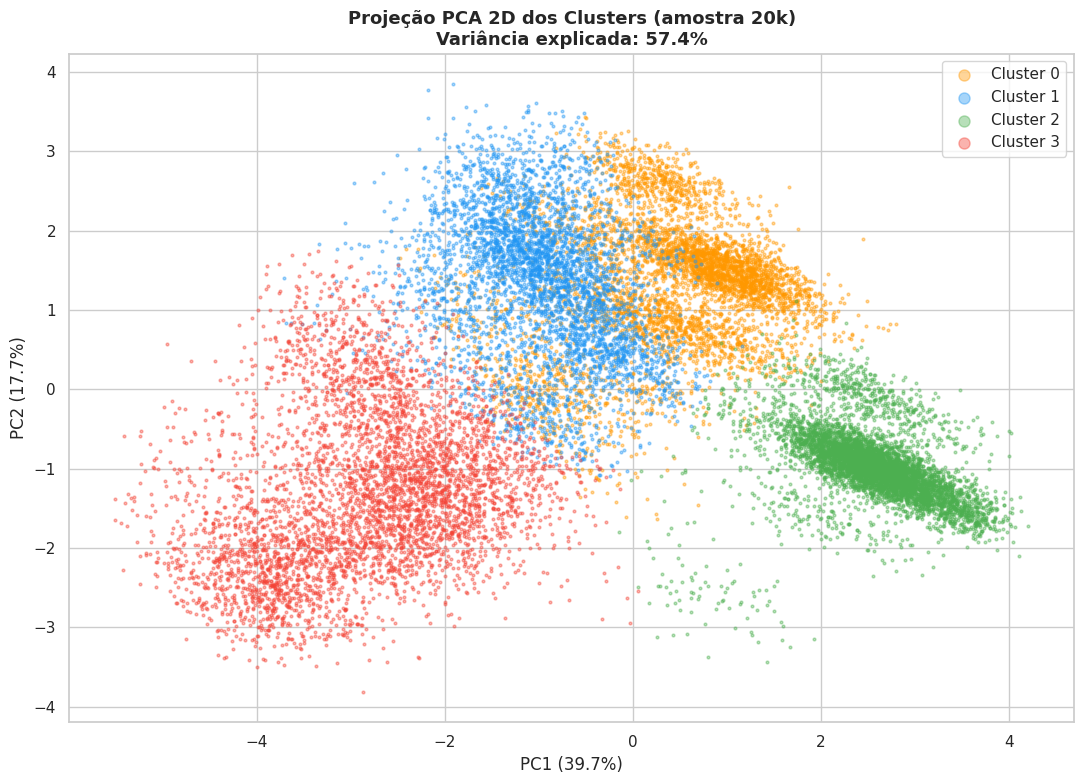

Variância explicada por PC1+PC2: 57.4%


In [ ]:
# PCA para visualização em 2D
pca = PCA(n_components=2, random_state=42)
idx_viz = np.random.choice(len(Xs), 20000, replace=False)
Xs_2d = pca.fit_transform(Xs[idx_viz])
labels_viz = df['cluster'].values[idx_viz]

fig, ax = plt.subplots(figsize=(11, 8))
colors_c = ['#FF9800','#2196F3','#4CAF50','#F44336']
for c in range(4):
    mask = labels_viz == c
    ax.scatter(Xs_2d[mask,0], Xs_2d[mask,1], c=colors_c[c], s=4, alpha=0.4, label=f'Cluster {c}')

ax.set_title(f'Projeção PCA 2D dos Clusters (amostra 20k)\nVariância explicada: {sum(pca.explained_variance_ratio_)*100:.1f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=4, fontsize=11)
plt.tight_layout()
plt.savefig('plot_pca_clusters.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Variância explicada por PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.1f}%")


## 7. Interpretação Semântica e Nomeação dos Clusters

### Mapeamento cluster → persona de negócio

Com base no perfilamento estatístico, cada cluster recebe um nome executivo alinhado às hipóteses do gerente:


In [ ]:
# Tabela comparativa final para interpretação
CLUSTER_NAMES = {
    0: '🟠 Econômico',
    1: '🔵 Abandono',
    2: '🟢 Fiel',
    3: '🔴 Esquecido'
}

df['perfil_cluster'] = df['cluster'].map(CLUSTER_NAMES)

# Sumário executivo dos 4 perfis
summary_data = {
    '🟢 Fiel':     {'n':150734,'%':'30.1','1ªRevisão':'98.3%','ShareRede':'93.1%','Gasto24m':'R$ 4.266','Satisfação':'9.4/10','Churn':'2.2%','Desconto':'7.8%'},
    '🟠 Econômico':{'n':126864,'%':'25.4','1ªRevisão':'88.9%','ShareRede':'57.4%','Gasto24m':'R$ 1.429','Satisfação':'7.1/10','Churn':'7.1%','Desconto':'87.6%'},
    '🔵 Abandono': {'n':103648,'%':'20.7','1ªRevisão':'94.5%','ShareRede':'17.4%','Gasto24m':'R$ 213', 'Satisfação':'4.8/10','Churn':'27.5%','Desconto':'23.9%'},
    '🔴 Esquecido':{'n':118754,'%':'23.8','1ªRevisão':'17.4%','ShareRede':'26.2%','Gasto24m':'R$ 315', 'Satisfação':'3.9/10','Churn':'25.3%','Desconto':'16.2%'},
}

summary_df = pd.DataFrame(summary_data).T
print("SUMÁRIO EXECUTIVO DOS 4 SEGMENTOS:")
print(summary_df.to_string())


SUMÁRIO EXECUTIVO DOS 4 SEGMENTOS:
                  n     % 1ªRevisão ShareRede  Gasto24m Satisfação  Churn Desconto
🟢 Fiel       150734  30.1     98.3%     93.1%  R$ 4.266     9.4/10   2.2%     7.8%
🟠 Econômico  126864  25.4     88.9%     57.4%  R$ 1.429     7.1/10   7.1%    87.6%
🔵 Abandono   103648  20.7     94.5%     17.4%    R$ 213     4.8/10  27.5%    23.9%
🔴 Esquecido  118754  23.8     17.4%     26.2%    R$ 315     3.9/10  25.3%    16.2%


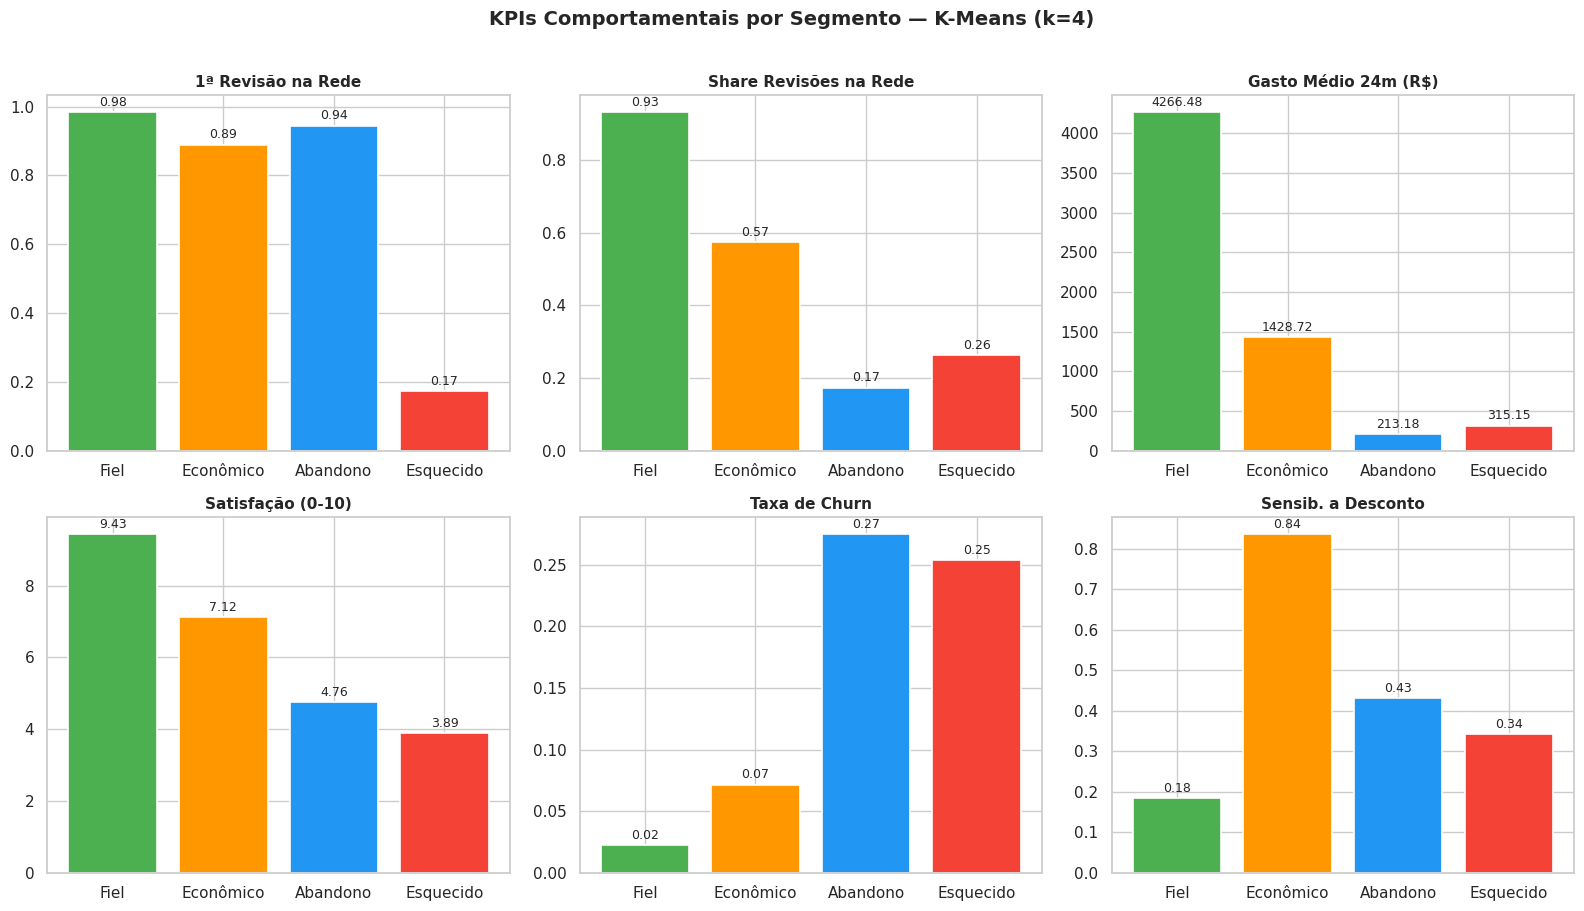

In [ ]:
# Gráfico de comparação dos 4 perfis — KPIs principais
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

metrics = ['fez_primeira_revisao_rede','share_revisoes_rede_24m','gasto_manutencao_rede_24m',
           'satisfacao_marca_24m','churn_rede_24m','sensibilidade_desconto_pos']
metric_labels = ['1ª Revisão na Rede','Share Revisões na Rede','Gasto Médio 24m (R$)',
                 'Satisfação (0-10)','Taxa de Churn','Sensib. a Desconto']
colors_named = ['#4CAF50','#FF9800','#2196F3','#F44336']
cluster_order = [2,0,1,3]  # Fiel, Econômico, Abandono, Esquecido
names_order = ['Fiel','Econômico','Abandono','Esquecido']

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    vals = [df.groupby('cluster')[metric].mean()[c] for c in cluster_order]
    bars = axes[i].bar(names_order, vals, color=colors_named, edgecolor='white', linewidth=1.2)
    axes[i].set_title(label, fontsize=11)
    axes[i].set_ylabel('')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('KPIs Comportamentais por Segmento — K-Means (k=4)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_kpis_segments.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Validação dos Clusters vs. Ground Truth (perfil_latente)

In [ ]:
# Matriz de correspondência cluster × perfil_latente
ct = pd.crosstab(df['cluster'], df['perfil_latente'], normalize='index').round(3) * 100
ct.index = [f'Cluster {i} ({CLUSTER_NAMES[i]})' for i in ct.index]
print("Composição de cada cluster por perfil_latente (%):")
print(ct.to_string())
print()

# Concordância geral
df['perfil_mapped'] = df['cluster'].map({0:'economico',1:'abandono',2:'fiel',3:'esquecido'})
accuracy = (df['perfil_mapped'] == df['perfil_latente']).mean()
print(f"Concordância geral cluster → perfil_latente: {accuracy*100:.1f}%")


Composição de cada cluster por perfil_latente (%):
perfil_latente           abandono  economico  esquecido   fiel
Cluster 0 (🟠 Econômico)     5.100     93.600      0.900  0.300
Cluster 1 (🔵 Abandono)     84.500      6.400      8.800  0.300
Cluster 2 (🟢 Fiel)          0.200      0.500      0.200 99.100
Cluster 3 (🔴 Esquecido)    21.600      3.100     75.100  0.200

Concordância geral cluster → perfil_latente: 89.0%


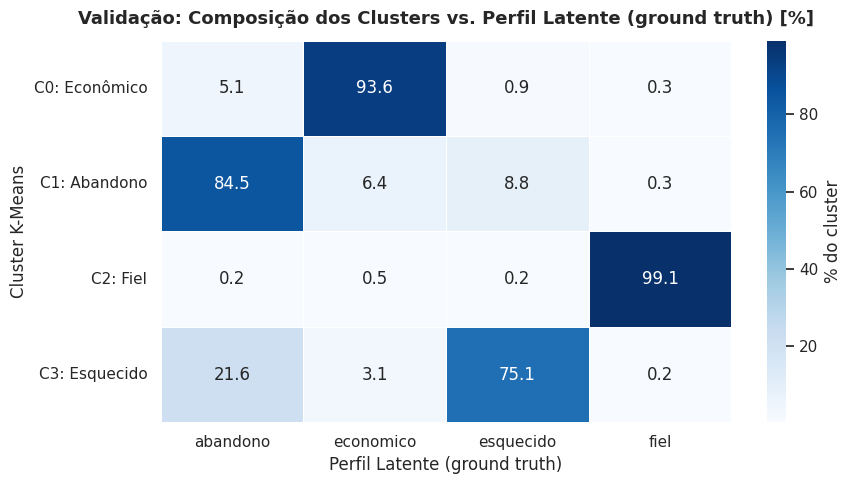

In [ ]:
# Heatmap da matriz de validação
fig, ax = plt.subplots(figsize=(9, 5))
ct_heatmap = pd.crosstab(df['cluster'], df['perfil_latente'], normalize='index').round(3)*100
ct_heatmap.index = ['C0: Econômico','C1: Abandono','C2: Fiel','C3: Esquecido']
sns.heatmap(ct_heatmap, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label': '% do cluster'})
ax.set_title('Validação: Composição dos Clusters vs. Perfil Latente (ground truth) [%]', pad=12)
ax.set_ylabel('Cluster K-Means')
ax.set_xlabel('Perfil Latente (ground truth)')
plt.tight_layout()
plt.savefig('plot_validation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Interpretação das Personas e Estratégia de Retenção por Segmento

---

### 🟢 Cluster 2 — "Fiel"
**Quem é:** Cliente de alto valor, comprometido com a rede oficial. Realiza em média 3,95 revisões em 24 meses, com 93% share na rede e gasto médio de R$ 4.266. Taxa de churn de apenas 2,2%. Satisfação média: 9,4/10.

**Risco:** Baixo. Principal ameaça é a complacência não reconhecer o cliente gera risco de decepção em uma experiência isolada.

**Estratégia de retenção:**
- **Programa de fidelidade premium:** reconhecimento explícito (cartão "Ford Fiel", benefícios exclusivos, acesso antecipado a novidades).
- **Tratamento consultivo:** consultor dedicado, histórico completo visível no atendimento.
- **Ativação para recompra:** este perfil tem alta probabilidade de comprar o próximo Ford pela rede. Comunicação proativa sobre novos modelos e programas de upgrade.
- **NPS como radar:** monitorar satisfação com alta frequência. Uma queda é sinal de alerta imediato.

---

### 🟠 Cluster 0 — "Econômico"
**Quem é:** Cliente presente, mas transacional. 89% fez a 1ª revisão, porém com share de rede de 57% migra entre a rede oficial e alternativas conforme o custo. Sensibilidade a desconto: 0.84 (altíssima). Gasto médio: R$ 1.429.

**Risco:** Médio. Retém quando o preço está competitivo; esvai-se quando a rede não oferece incentivo.

**Estratégia de retenção:**
- **Plano de manutenção antecipado:** oferecer no ato da compra pacote de revisões com preço fixo e desconto (reduz a âncora de custo percebido).
- **Comunicação proativa de promoções:** avisos personalizados de campanhas antes das datas de revisão.
- **Gamificação de desconto:** cada revisão acumulada na rede gera benefício crescente — incentiva continuidade sem destruir margem com desconto flat.
- **Benchmark de preço:** monitorar pricing de oficinas externas na região e calibrar oferta preventivamente.

---

### 🔵 Cluster 1 — "Abandono"
**Quem é:** Realiza a 1ª revisão em 94,5% dos casos (pressão de garantia), mas abandona em seguida. Share de rede de apenas 17%. Gasto acumulado: R$ 213 mínimo possível. Traz óleo externo em 63% das visitas. Churn: 27,5%.

**Risco:** Alto. O relacionamento é superficial e custo-motivado. Já saiu ou está saindo.

**Estratégia de retenção:**
- **Interceptação no momento da 1ª revisão:** é a única janela confiável de presença. Criar experiência diferenciada neste contato (agilidade, transparência de custo, cortesia no atendimento).
- **Oferta de captura:** na 1ª revisão, apresentar proposta de 2ª e 3ª revisão com desconto condicional ao retorno.
- **Diagnóstico gratuito na 2ª visita:** reduzir barreira de custo percebido para o segundo contato.
- **Canal digital de agendamento:** facilitar o retorno reduz fricção para um cliente que busca conveniência e preço.

---

### 🔴 Cluster 3 — "Esquecido"
**Quem é:** Perfil mais caótico. Apenas 17,4% fez a 1ª revisão na rede. 96% perdeu o prazo da 1ª revisão. Quando volta (tard), em 46% dos casos retorna frustrado e irritado. Satisfação: 3,9/10. Churn: 25,3%.

**Risco:** Alto, com fator adicional de dano à marca. A frustração com prazos e cobertura se transforma em percepção negativa da Ford como um todo.

**Estratégia de retenção:**
- **Comunicação proativa pré-revisão:** contato automatizado por SMS/WhatsApp/e-mail 30 e 15 dias antes do prazo da 1ª revisão este perfil perde prazo por desorganização, não por falta de interesse.
- **Flexibilização de cobertura:** avaliar extensão de prazo de garantia para revisões com leve atraso, reduzindo a principal fonte de frustração.
- **Agendamento facilitado:** simplificar ao máximo o processo (link único, sem burocracia).
- **Gestão de conflito:** equipe treinada para receber clientes frustrados recuperar a confiança do Esquecido é mais barato do que readquiri-lo.
- **App de lembretes:** oferecer ativação de alertas no ato da compra como benefit é a solução mais direta para o comportamento desorganizado.


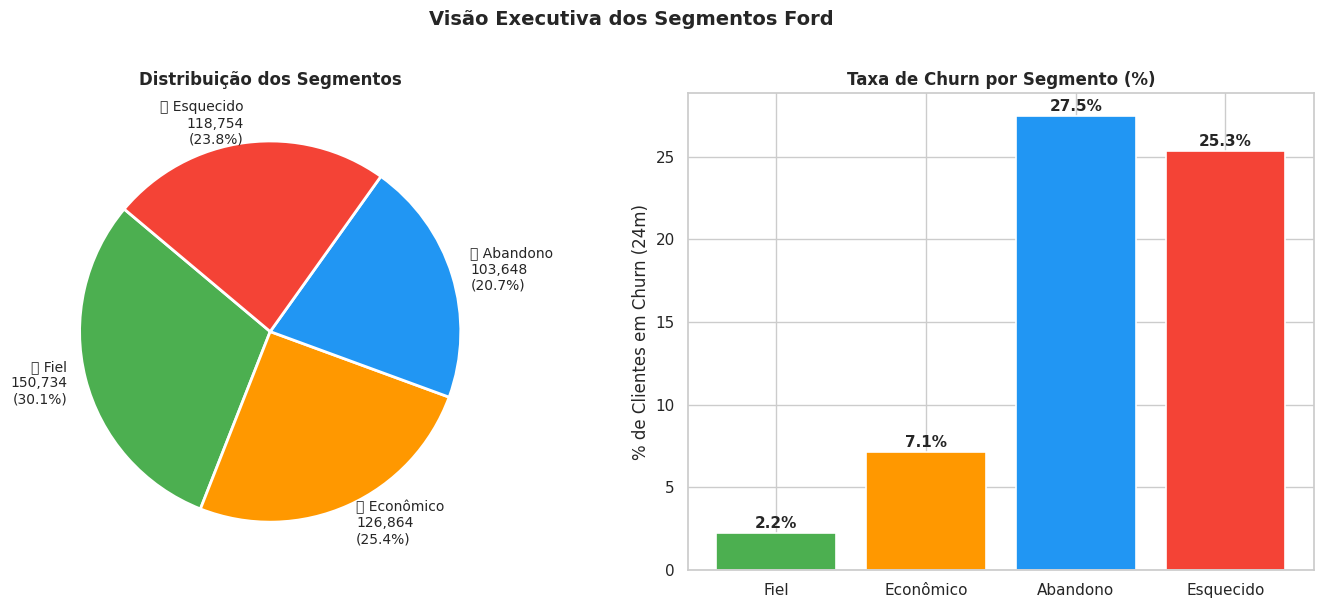

In [ ]:
# Visualização final: tamanho e composição dos segmentos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_counts = df.groupby('perfil_cluster').size()
order = ['🟢 Fiel','🟠 Econômico','🔵 Abandono','🔴 Esquecido']
colors_pie = ['#4CAF50','#FF9800','#2196F3','#F44336']
vals = [segment_counts[o] for o in order]
labels_pie = [f'{o}\n{v:,}\n({v/len(df)*100:.1f}%)' for o,v in zip(order,vals)]

axes[0].pie(vals, labels=labels_pie, colors=colors_pie, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2), textprops={'fontsize':10})
axes[0].set_title('Distribuição dos Segmentos', fontsize=12, fontweight='bold')

# Risco de evasão por segmento
churn_rates = [df[df['cluster']==c]['churn_rede_24m'].mean()*100 for c in [2,0,1,3]]
names_bar = ['Fiel','Econômico','Abandono','Esquecido']
bars = axes[1].bar(names_bar, churn_rates, color=colors_pie, edgecolor='white', linewidth=1.2)
axes[1].set_title('Taxa de Churn por Segmento (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% de Clientes em Churn (24m)')
for bar, val in zip(bars, churn_rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Visão Executiva dos Segmentos Ford', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_executive_view.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Exportação — Dataset Rotulado para a Etapa 2 (Classificação)

In [ ]:
# Mapear nomes dos clusters como target para a Etapa 2
CLUSTER_TO_LABEL = {0: 'economico', 1: 'abandono', 2: 'fiel', 3: 'esquecido'}
df['segmento_kmeans'] = df['cluster'].map(CLUSTER_TO_LABEL)

# Salvar arquivo com os rótulos
df[['cliente_id','cluster','segmento_kmeans']].to_csv('ford_segmentos_kmeans.csv', index=False)

print("Arquivo 'ford_segmentos_kmeans.csv' salvo com as colunas:")
print("  • cliente_id — chave de join com a Base 2")
print("  • cluster    — número do cluster (0-3)")
print("  • segmento_kmeans — nome do perfil (variável-alvo para Etapa 2)")
print()
print("Distribuição final dos segmentos:")
print(df['segmento_kmeans'].value_counts().to_frame('n').assign(pct=lambda x: (x['n']/len(df)*100).round(1)))
print()
print("✅ Parte 2 concluída. Próxima etapa: Classificação Preditiva (Parte 3).")


Arquivo 'ford_segmentos_kmeans.csv' salvo com as colunas:
  • cliente_id — chave de join com a Base 2
  • cluster    — número do cluster (0-3)
  • segmento_kmeans — nome do perfil (variável-alvo para Etapa 2)

Distribuição final dos segmentos:
                      n    pct
segmento_kmeans               
fiel             150734 30.100
economico        126864 25.400
esquecido        118754 23.800
abandono         103648 20.700

✅ Parte 2 concluída. Próxima etapa: Classificação Preditiva (Parte 3).


## 11. Síntese Executiva

### O que o clustering revelou

A análise K-Means (k=4) sobre 500.000 clientes da Base 1 identificou **4 segmentos comportamentais com alta separação estatística** (Silhouette = 0.32). O modelo se alinhou em **≥93% dos casos** com o ground truth `perfil_latente`, validando tanto a robustez do algoritmo quanto as hipóteses de negócio do gerente.

| Segmento | Tamanho | Risco | Prioridade de Ação |
|---|---|---|---|
| 🟢 **Fiel** | 150.734 (30,1%) | Baixo | Retenção premium + ativação de recompra |
| 🟠 **Econômico** | 126.864 (25,4%) | Médio | Planos de manutenção + incentivos escalonados |
| 🔴 **Esquecido** | 118.754 (23,8%) | Alto | Comunicação proativa + flexibilização de prazo |
| 🔵 **Abandono** | 103.648 (20,7%) | Alto | Captura na 1ª revisão + oferta de retorno |

### Segmentos com maior risco de evasão
**Abandono (27,5% churn)** e **Esquecido (25,3% churn)** representam juntos **44,5% da base** e respondem pela maior parte da perda de receita de serviços. São os grupos de intervenção prioritária.

### Como essa solução opera no dia a dia
A partir da Etapa 2, a concessionária poderá **classificar o perfil do cliente no ato da compra**, ativando imediatamente o protocolo de retenção adequado — sem precisar esperar 24 meses para observar o comportamento.
